# CREDIT GUARD(AI-powered credit card risk analysis system)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
colors = sb.color_palette("crest", 2)


In [2]:
a = pd.read_csv("../Datasets/Applications_cc.csv")

In [3]:
a

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


In [4]:
b = pd.read_csv("../Datasets/credit_record _cc.csv")

In [5]:
b

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


In [6]:
common=a[a["ID"].isin(b["ID"])]

In [7]:
common

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434808,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0
434809,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0
434810,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0
434811,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0


* **Cleaning Duplicate values in Dataset**

In [8]:
a_cleaned= a.drop_duplicates(subset=['ID'],keep='first')
b_cleaned=b.drop_duplicates(subset=['ID'],keep='first')


In [9]:
a_cleaned

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


In [10]:
b_cleaned

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
4,5001712,0,C
23,5001713,0,X
45,5001714,0,X
60,5001715,0,X
...,...,...,...
1048494,5150482,-11,C
1048512,5150483,0,X
1048530,5150484,0,C
1048543,5150485,0,0


* **Merging both the dataset for performing EDA**

In [11]:
df=pd.merge(a_cleaned,b_cleaned,on='ID',how='inner')

In [12]:
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0,C
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,-22,X
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,-17348,-2420,1,0,0,0,Managers,2.0,0,5
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,0,C
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,1,0,1,1,Medicine staff,2.0,0,C
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,-17958,-655,1,0,0,0,Sales staff,2.0,0,2


*  **Cleaning the dataset**

In [13]:
df.isnull().sum()

ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
FLAG_MOBIL                 0
FLAG_WORK_PHONE            0
FLAG_PHONE                 0
FLAG_EMAIL                 0
OCCUPATION_TYPE        11323
CNT_FAM_MEMBERS            0
MONTHS_BALANCE             0
STATUS                     0
dtype: int64

In [14]:
df.NAME_EDUCATION_TYPE.unique()

array(['Higher education', 'Secondary / secondary special',
       'Incomplete higher', 'Lower secondary', 'Academic degree'],
      dtype=object)

In [15]:
df.NAME_EDUCATION_TYPE=df.NAME_EDUCATION_TYPE.replace("Secondary / secondary special","Secondary special")

In [16]:
df.NAME_FAMILY_STATUS.unique()

array(['Civil marriage', 'Married', 'Single / not married', 'Separated',
       'Widow'], dtype=object)

In [17]:
df.NAME_FAMILY_STATUS=df.NAME_FAMILY_STATUS.replace("Single / not married","Single")

In [18]:
df.NAME_HOUSING_TYPE.unique()

array(['Rented apartment', 'House / apartment', 'Municipal apartment',
       'With parents', 'Co-op apartment', 'Office apartment'],
      dtype=object)

In [19]:
df.NAME_HOUSING_TYPE=df.NAME_HOUSING_TYPE.replace("House / apartment","House")

In [20]:
df.OCCUPATION_TYPE = df.OCCUPATION_TYPE.fillna("Unknown")

In [21]:
df.OCCUPATION_TYPE.unique()

array(['Unknown', 'Security staff', 'Sales staff', 'Accountants',
       'Laborers', 'Managers', 'Drivers', 'Core staff',
       'High skill tech staff', 'Cleaning staff', 'Private service staff',
       'Cooking staff', 'Low-skill Laborers', 'Medicine staff',
       'Secretaries', 'Waiters/barmen staff', 'HR staff', 'Realty agents',
       'IT staff'], dtype=object)

In [22]:
df.OCCUPATION_TYPE=df.OCCUPATION_TYPE.replace("Waiters/barmen staff","Waiters")

In [23]:
df.STATUS.unique()

array(['C', '0', 'X', '1', '5', '3', '4', '2'], dtype=object)

In [24]:
status_map = {
    '0': 0,
    '1': 0,
    '2': 1,
    '3': 1,
    '4': 1,
    '5': 1,
    'C': 0,
    'X': 0
}
df['CREDIT_RISK'] = df.STATUS.map(status_map)


In [25]:
df.CREDIT_RISK.value_counts()

CREDIT_RISK
0    36351
1      106
Name: count, dtype: int64

In [26]:
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,CREDIT_RISK
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,0,C,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,0,C,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary special,Married,House,...,-1134,1,0,0,0,Security staff,2.0,0,C,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary special,Single,House,...,-3051,1,0,1,1,Sales staff,1.0,0,0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary special,Single,House,...,-3051,1,0,1,1,Sales staff,1.0,-22,X,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary special,Married,House,...,-2420,1,0,0,0,Managers,2.0,0,5,1
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House,...,-1325,1,0,1,1,Medicine staff,2.0,0,C,0
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House,...,-1325,1,0,1,1,Medicine staff,2.0,0,C,0
36455,5150049,F,N,Y,0,283500.0,Working,Secondary special,Married,House,...,-655,1,0,0,0,Sales staff,2.0,0,2,1


*  **Identifying what dataset is having by using shape,columns and data types**

In [27]:
print("Shape:", df.shape)
print(df.columns)
print(df.dtypes)

Shape: (36457, 21)
Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'MONTHS_BALANCE',
       'STATUS', 'CREDIT_RISK'],
      dtype='object')
ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
MONTHS_

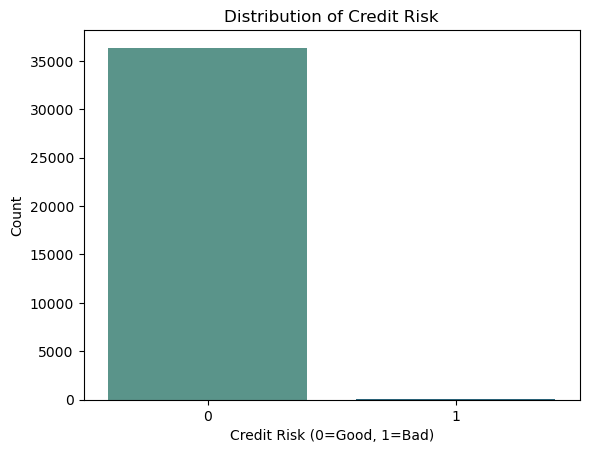

CREDIT_RISK
0    36351
1      106
Name: count, dtype: int64


In [28]:
import warnings
warnings.filterwarnings('ignore')
sb.countplot( x=df.CREDIT_RISK,palette='crest')
plt.title("Distribution of Credit Risk")
plt.xlabel("Credit Risk (0=Good, 1=Bad)")
plt.ylabel("Count")
plt.show()
print(df.CREDIT_RISK.value_counts())

* The **CREDIT_RISK distribution** is highly imbalanced, with **36,351 customers (99.71%)** classified as **Good Credit (0)** and only **106 customers** (0.29%) classified as **Bad Credit (1)**.

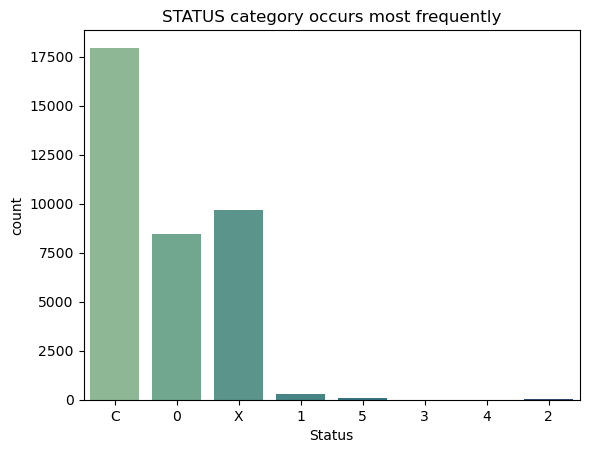

STATUS
C    17950
X     9669
0     8456
1      276
5       76
2       19
3        6
4        5
Name: count, dtype: int64


In [29]:
import warnings
warnings.filterwarnings('ignore')
sb.countplot(x=df.STATUS,palette='crest')
plt.title("STATUS category occurs most frequently")
plt.xlabel("Status")
plt.ylabel("count")
plt.show()
print(df.STATUS.value_counts())

* The majority of customers have **closed loans (C)**, **no loan activity (X)**, or have **paid on time (0)**, indicating a generally good repayment history. 
* **Late payment** and **default statuses (1–5)** are very rare, suggesting that only a small proportion of customers exhibit credit risk.

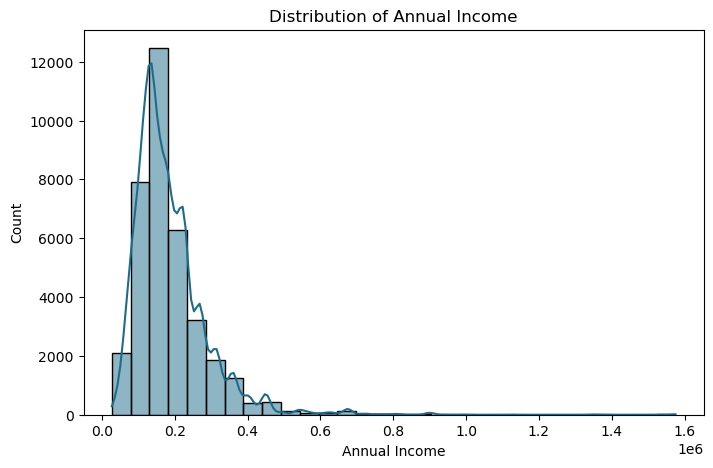

In [30]:
plt.figure(figsize=(8,5))
sb.histplot(x=df.AMT_INCOME_TOTAL, bins=30, kde=True,color=colors[1])
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.show()

* The **annual income distribution** is **right-skewed**, with most customers earning between **100,000 and 250,000**.
* A few customers have very high incomes, creating a **long right tail** and indicating the presence of **high-income outliers**.

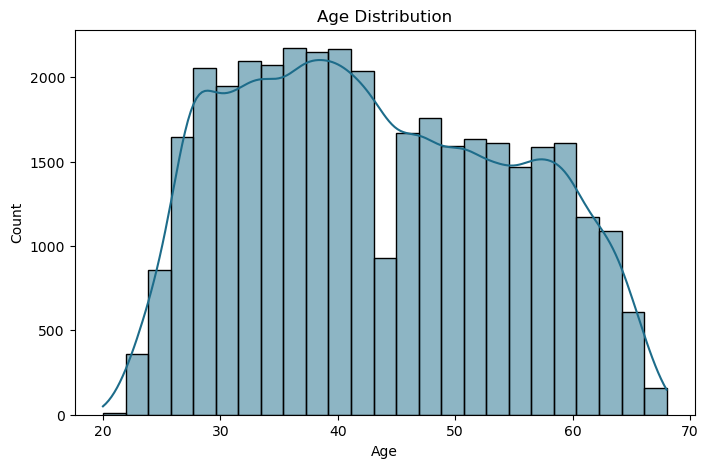

In [31]:
df['AGE'] =(-df["DAYS_BIRTH"] // 365)
plt.figure(figsize=(8,5))
sb.histplot(x=df.AGE,bins=25,kde=True,color=colors[1])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

* The age distribution shows that most customers are between **30 and 60 years old**, with the highest concentration around **35–40 years**. 
* The dataset contains relatively **fewer young (below 25)** and **older (above 65)** customers.

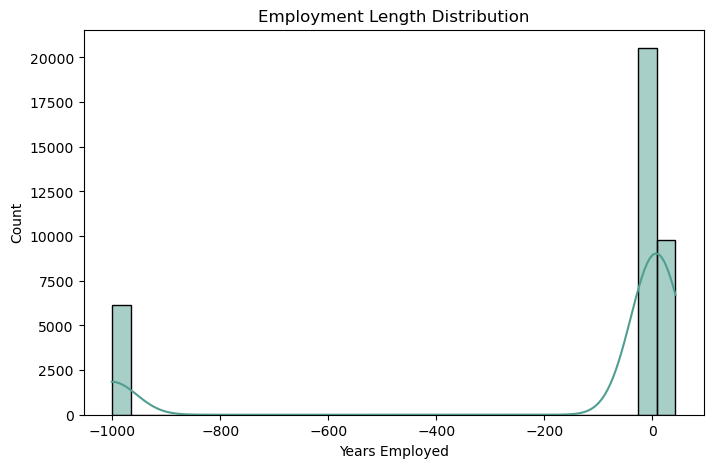

In [32]:
df['EMPLOYMENT_YEARS']=(-df["DAYS_EMPLOYED"] / 365)
plt.figure(figsize=(8,5))
sb.histplot(x=df.EMPLOYMENT_YEARS,bins=30,kde=True,color=colors[0])
plt.title("Employment Length Distribution")
plt.xlabel("Years Employed")
plt.show()

* The employment length distribution is concentrated between **0 and 40 years**, with most customers having **relatively shorter employment durations**. 
* The large spike at **-1001 years** represents the placeholder value (DAYS_EMPLOYED = 365243) **used for pensioners** or customers who are not currently employed, rather than actual employment length.

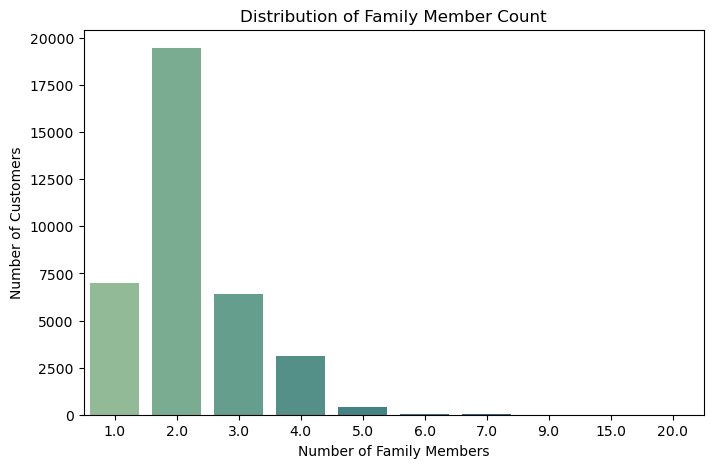

CNT_FAM_MEMBERS
2.0     19463
1.0      6987
3.0      6421
4.0      3106
5.0       397
6.0        58
7.0        19
15.0        3
9.0         2
20.0        1
Name: count, dtype: int64


In [33]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(8,5))
sb.countplot(x=df.CNT_FAM_MEMBERS,order=df.CNT_FAM_MEMBERS.value_counts().sort_index().index,palette='crest')
plt.title("Distribution of Family Member Count")
plt.xlabel("Number of Family Members")
plt.ylabel("Number of Customers")
plt.show()
print(df.CNT_FAM_MEMBERS.value_counts())

* The majority of customers have **2 family members**, followed by 1 and 3 family members, indicating that small families are the **most common** in the dataset. 
* Customers with **more than 5 family members** are very rare, making larger families uncommon.

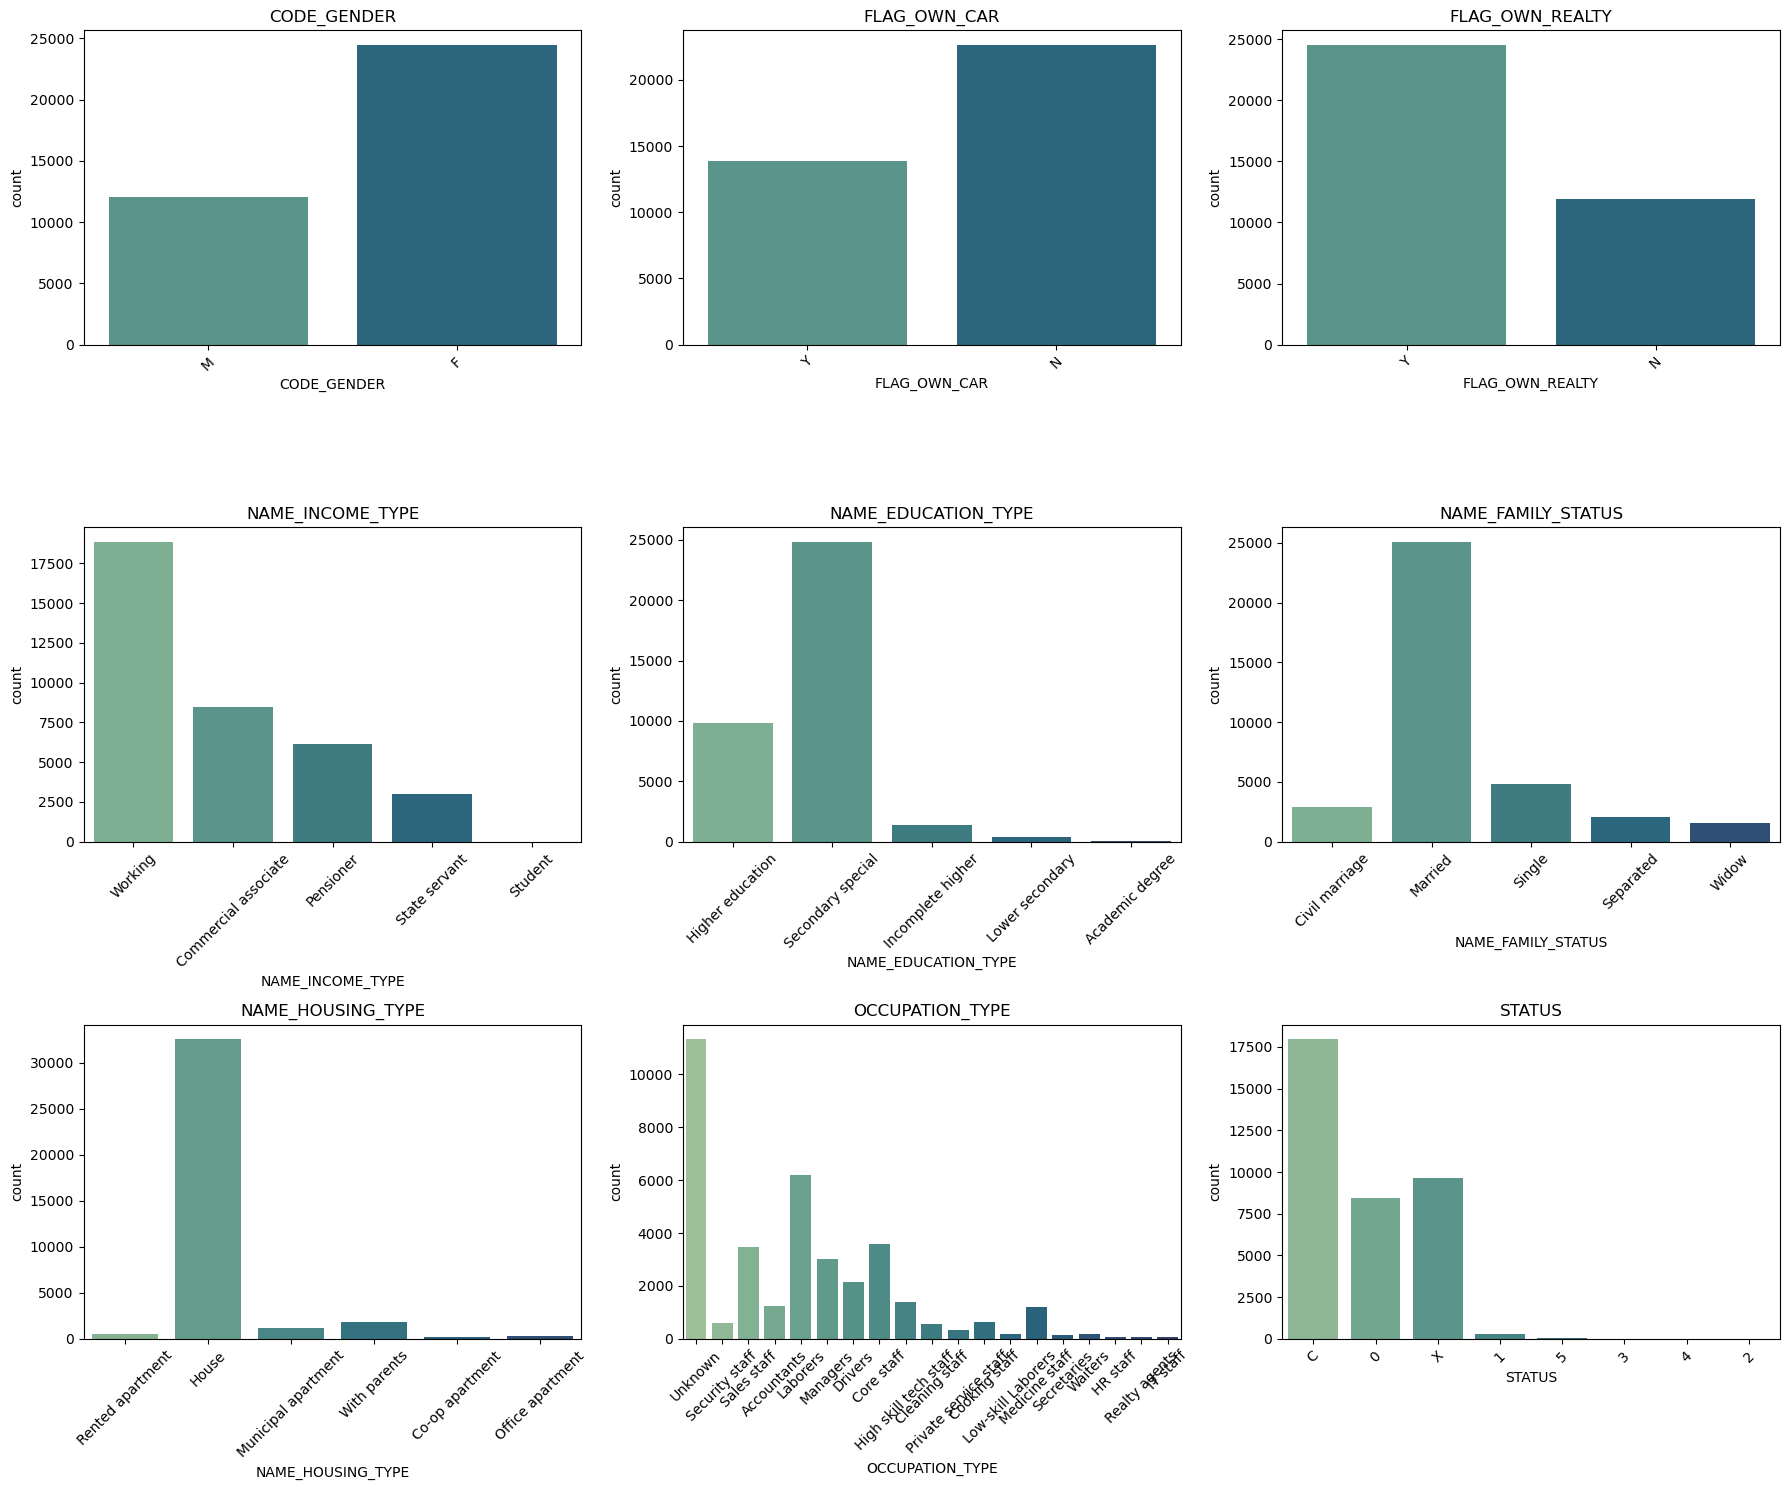

In [34]:
import warnings
warnings.filterwarnings('ignore')
categorical_cols = [
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'STATUS'
]
plt.figure(figsize=(18, 15))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)  
    sb.countplot(data=df, x=col,palette='crest')
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

* **Most customers are female, do not own a car, but own a house/property. The majority are working, have secondary education, are married, and live in their own house, while loan closed (C), no loan activity (X), and paid on time (0) are the most common credit statuses**.

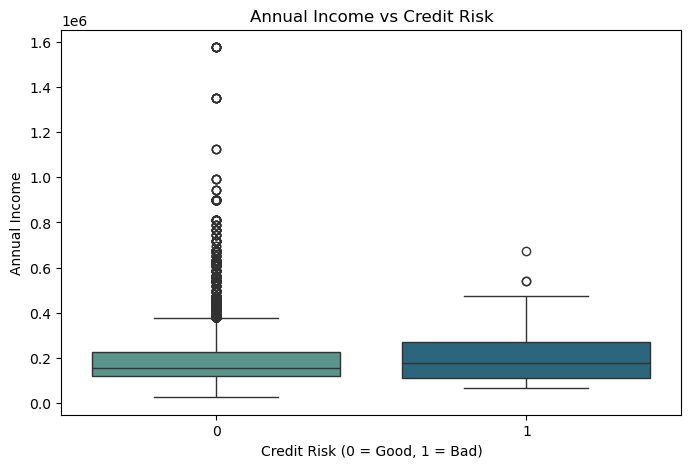

In [35]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(8,5))
sb.boxplot( x=df.CREDIT_RISK, y=df.AMT_INCOME_TOTAL,palette='crest')
plt.title("Annual Income vs Credit Risk")
plt.xlabel("Credit Risk (0 = Good, 1 = Bad)")
plt.ylabel("Annual Income")
plt.show()

* Customers with **good credit (0)** and **bad credit (1)** have similar **median annual incomes**, although the **bad credit group** has a **slightly higher median**. The **good credit group** contains **many more high-income outliers**, **indicating greater variability** in annual income.

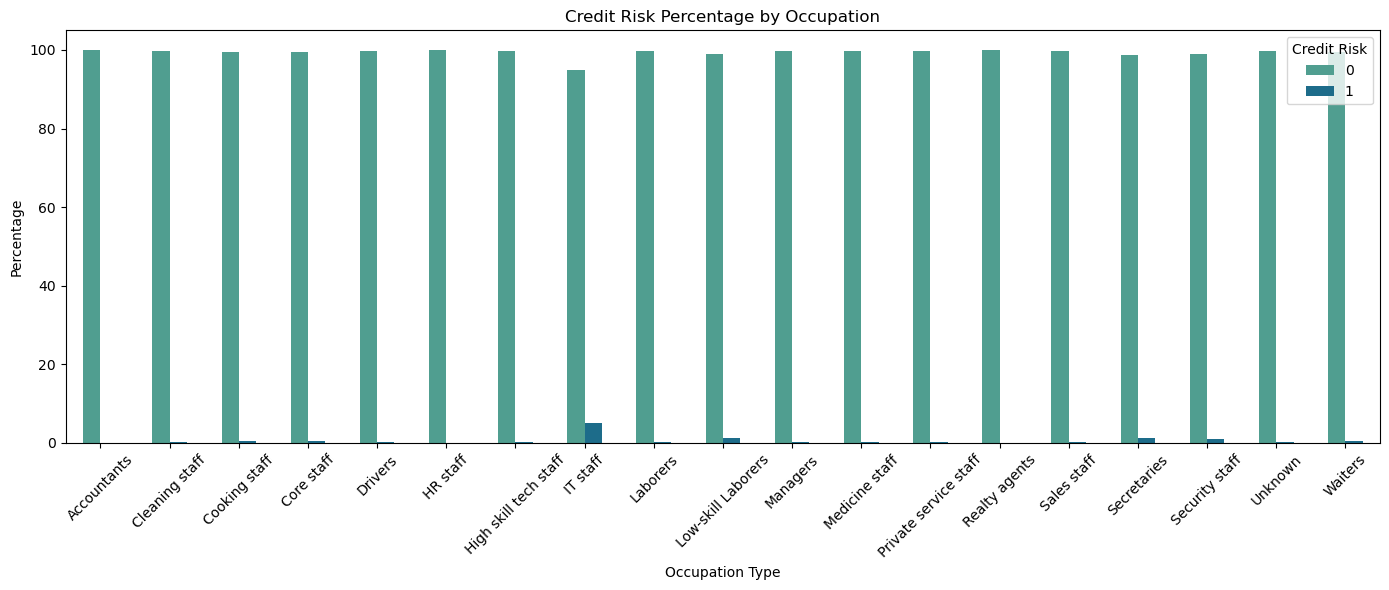

CREDIT_RISK,0,1
OCCUPATION_TYPE,,
Accountants,100.000000,0.000000
Cleaning staff,99.818512,0.181488
Cooking staff,99.541985,0.458015
Core staff,99.610136,0.389864
Drivers,99.719364,0.280636
HR staff,100.000000,0.000000
High skill tech staff,99.638467,0.361533
IT staff,95.000000,5.000000
Laborers,99.774593,0.225407


In [36]:
occupation_risk = pd.crosstab(df.OCCUPATION_TYPE,df.CREDIT_RISK,normalize='index') * 100
occupation_risk.plot(kind='bar',figsize=(14,6),color=colors)
plt.title("Credit Risk Percentage by Occupation")
plt.xlabel("Occupation Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Credit Risk")
plt.tight_layout()
plt.show()
occupation_risk

* Most occupation types have a **very high proportion of good credit customers (over 98%)**, indicating generally low credit risk across occupations. **Secretaries (1.32%), Low-skill Laborers (1.14%), and Security staff (1.01%) have the highest percentages of bad credit customers**, although the overall bad credit rate remains low.

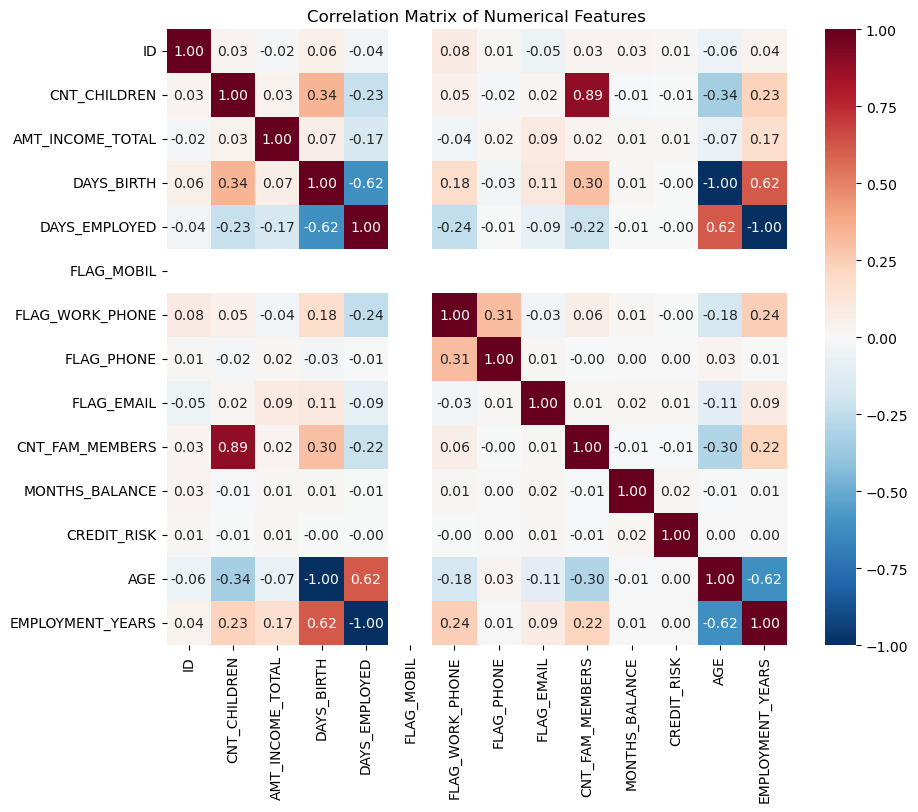

In [37]:
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
correlation = numerical_cols.corr()
plt.figure(figsize=(10, 8))
sb.heatmap(correlation,annot=True,cmap='RdBu_r',fmt='.2f')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

* **Most numerical features show weak correlations**, indicating limited linear relationships between them.
* The **strongest positive correlation** is between **CNT_CHILDREN and CNT_FAM_MEMBERS (0.89)**, while **AGE and EMPLOYMENT_YEARS (0.62) are positively correlated**, and **AGE and DAYS_BIRTH (-1.00) exhibit a perfect negative correlation** because age is derived directly from DAYS_BIRTH.

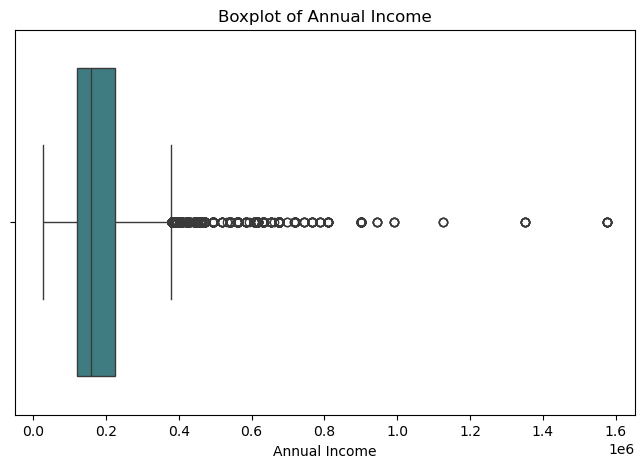

In [38]:
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(8,5))
sb.boxplot(x=df.AMT_INCOME_TOTAL,palette='crest')
plt.title("Boxplot of Annual Income")
plt.xlabel("Annual Income")
plt.show()

* The boxplot indicates the presence of several extreme high-income outliers, with a **few customers earning significantly more than the majority**. **Most customers have annual incomes within a relatively narrow range**, while only a small number fall far beyond the upper whisker.

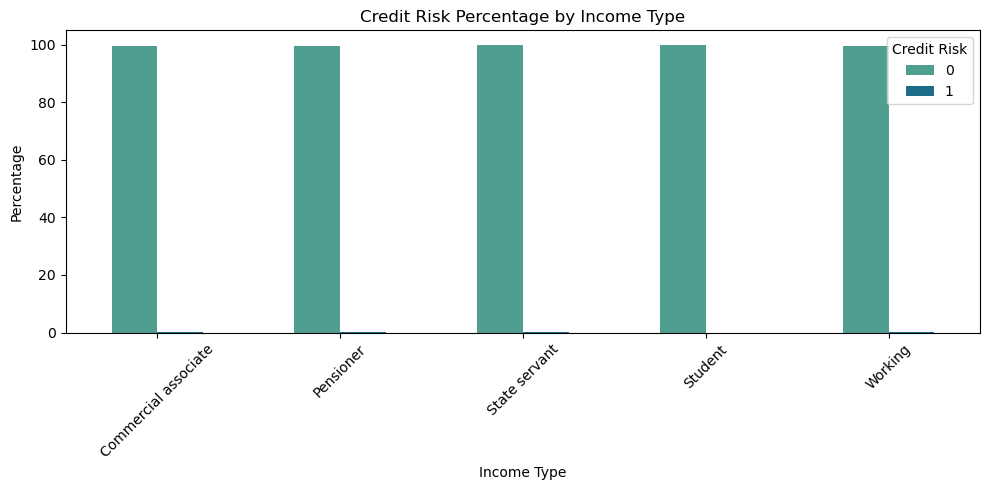

CREDIT_RISK                    0         1
NAME_INCOME_TYPE                          
Commercial associate   99.646643  0.353357
Pensioner              99.658648  0.341352
State servant          99.932998  0.067002
Student               100.000000  0.000000
Working                99.718370  0.281630


In [39]:
income_risk = pd.crosstab(df.NAME_INCOME_TYPE,df.CREDIT_RISK,normalize='index') * 100
income_risk.plot(kind='bar',figsize=(10,5),color=colors)
plt.title("Credit Risk Percentage by Income Type")
plt.xlabel("Income Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title='Credit Risk')
plt.tight_layout()
plt.show()
print(income_risk)

* All income types have an extremely high proportion of good credit customers (above 99%), indicating a very low overall default rate.
* **Commercial associates (0.35%) and Pensioners (0.34%) have slightly higher bad credit rates**, while Students and State servants exhibit the lowest credit risk.